In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import datetime , timedelta
import pandas as pd
import matplotlib.dates as mdates
import io
from PIL import Image
from folium.plugins import HeatMap
import folium
import os
import colorgram 
import kaleido
import plotly.express as px


figures_path = os.path.join('figures')

monthly_metrics_path = 'data/monthly_metrics.csv'
observations_path = 'data/observations.csv'


palette = ['#2b2e4f', '#f85532', '#fe5631', '#f95532', '#2a2e4f']

Paleta de colores : 

# 1.Graficación y muestra de métricas principales

1.1. número de observaciones, número de observadores, identificadores y especies
1.2. variación respecto al mes anterior

Estas métricas se mostrarán en forma de tabla debido a que es la mejor opción disponible 

# 2.Graficación evolución mensual de las metricas principales

Gráficos por observaciones, observadores, idntificadores y especies

2.1.Grafico observaciones

In [13]:
def get_observations_month():
    
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")
    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['observations'],
        palette=palette
    )

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2, 
            height + height * 0.0010,             
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f" Observations in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of observations")
    plt.tight_layout()
    output_path = os.path.join(figures_path, 'observations_plot.png')
    plt.savefig(output_path, dpi=300, bbox_inches='tight')
    plt.show()

C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2704364134.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last_month['year'] = df_last_month['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2704364134.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2704364134.py:15: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.barplot(


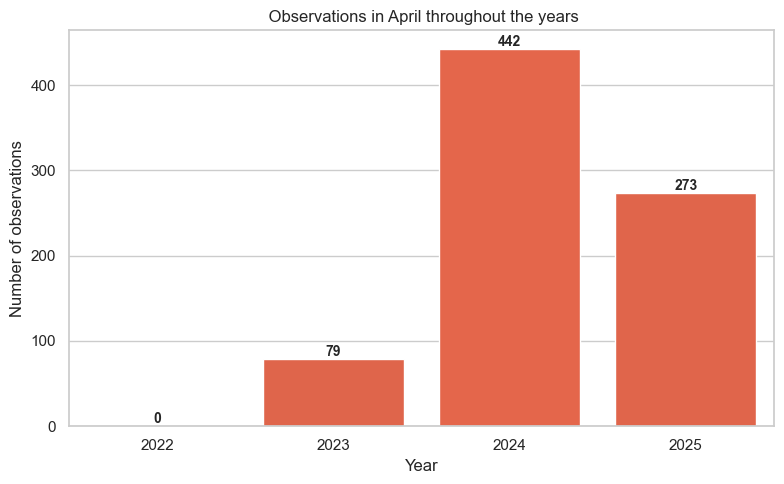

In [14]:
get_observations_month()

In [11]:
def get_observations_comp():

    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b') 
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='observations',
        hue='year',
        palette=palette,
    )

    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of observations')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\3914796674.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\3914796674.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\3914796674.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

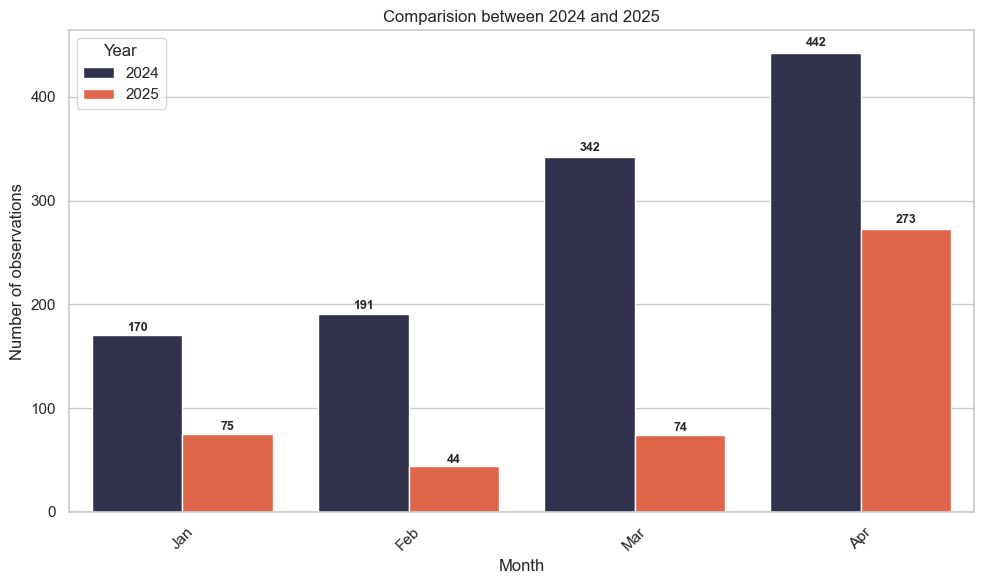

In [16]:
get_observations_comp()

2.2 Grafico observers

In [10]:
def get_observers_month():

    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['observers'],
        palette=palette
    )

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centrado
            height + height * 0.0010,             # Un poco encima de la barra
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f"Observers in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of observers")
    plt.tight_layout()
    plt.show()

C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\827716945.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last_month['year'] = df_last_month['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\827716945.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\827716945.py:16: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.barplot(


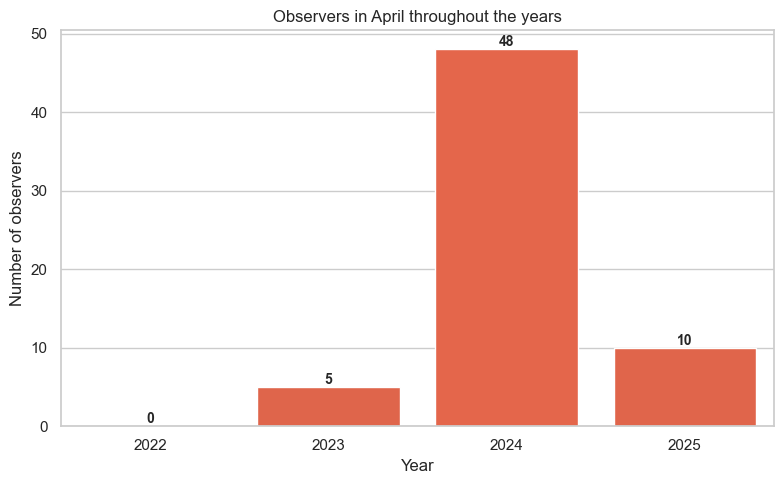

In [17]:
get_observers_month()

In [6]:
def get_observers_comp():

    df = pd.read_csv(monthly_metrics_path)

    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='observers',
        hue='year',
        palette=palette,
    )

    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )

    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of observers')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\826740569.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\826740569.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\826740569.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using

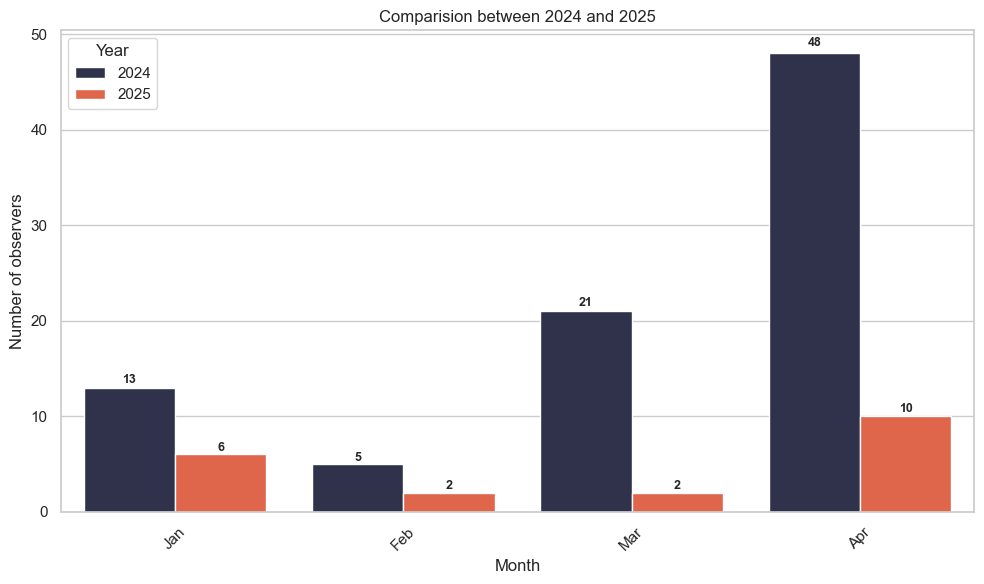

In [18]:
get_observers_comp()

2.3. Grafico identificadores

In [7]:
def get_identifers_month():
    
  
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['identifiers'],
        palette=palette
    )

    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centrado
            height + height * 0.0010,             # Un poco encima de la barra
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f" Identifiers in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of identifiers")
    plt.tight_layout()
    plt.show()

C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2712721358.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last_month['year'] = df_last_month['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2712721358.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2712721358.py:17: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.barplot(


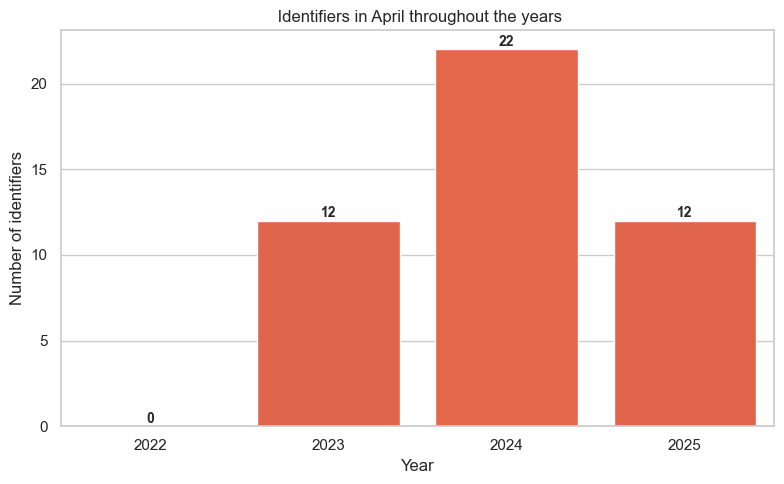

In [19]:
get_identifers_month()

In [8]:
def get_identifers_comp():
         
    df = pd.read_csv(monthly_metrics_path)

    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b') 
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='identifiers',
        hue='year',
        palette=palette,
    )


    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )


    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of identifiers')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\3693559948.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\3693559948.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\3693559948.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

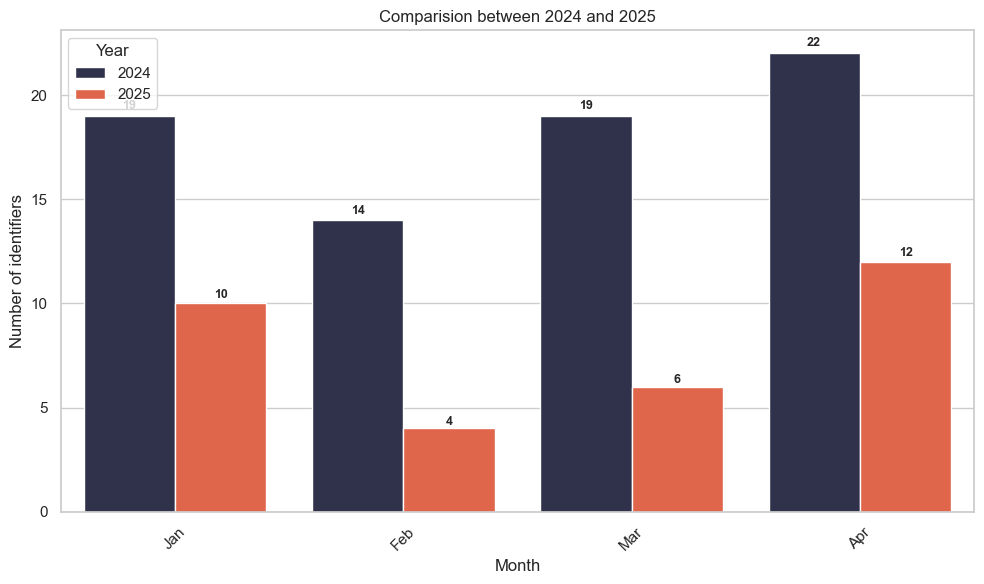

In [20]:
get_identifers_comp()

2.4. Grafico species

In [9]:
def get_species_month():
    
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    today = datetime.today()
    first_day_actual_month = datetime(today.year, today.month, 1)
    first_day_last_month = first_day_actual_month - pd.DateOffset(months=1)

    df_last_month = df[df['month'].dt.month == first_day_last_month.month]
    df_last_month['year'] = df_last_month['month'].dt.year

    sns.set(style="whitegrid")

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        x=df_last_month['year'].astype(str),
        y=df_last_month['species'],
        palette=palette
    )


    for bar in ax.patches:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,  # Centrado
            height + height * 0.0010,             # Un poco encima de la barra
            f'{int(height)}',
            ha='center',
            va='bottom',
            fontsize=10,
            fontweight='bold'
        )

    plt.title(f"Species in {first_day_last_month.strftime('%B')} throughout the years")
    plt.xlabel("Year")
    plt.ylabel("Number of species")
    plt.tight_layout()
    plt.show()

C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2647579487.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_last_month['year'] = df_last_month['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2647579487.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2647579487.py:16: UserWarning: The palette list has more values (5) than needed (4), which may not be intended.
  ax = sns.barplot(


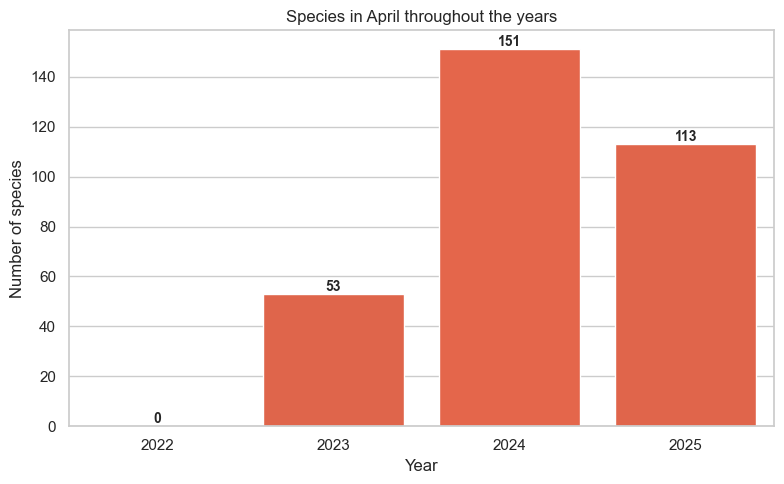

In [21]:
get_species_month()

In [5]:
def get_species_comp():
    df = pd.read_csv(monthly_metrics_path)
    df['month'] = pd.to_datetime(df['month'])

    current_year = datetime.today().year
    current_month = datetime.today().month

    df_filtered = df[
        ((df['month'].dt.year == current_year) & (df['month'].dt.month < current_month)) |
        ((df['month'].dt.year == current_year - 1) & (df['month'].dt.month < current_month))
    ]

    df_filtered['year'] = df_filtered['month'].dt.year
    df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')  
    df_filtered['month_number'] = df_filtered['month'].dt.month  

    df_filtered = df_filtered.sort_values('month_number')

    sns.set(style="whitegrid")
    plt.figure(figsize=(10, 6))

    ax = sns.barplot(
        data=df_filtered,
        x='month_name',
        y='species',
        hue='year',
        palette=palette,
    )


    for bar in ax.patches:
        height = bar.get_height()
        if height > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + height * 0.01,
                f'{int(height)}',
                ha='center',
                va='bottom',
                fontsize=9,
                fontweight='bold'
            )


    plt.title(f'Comparision between {current_year - 1} and {current_year}')
    plt.xlabel('Month')
    plt.ylabel('Number of species')
    plt.xticks(rotation=45)
    plt.legend(title='Year', loc='upper left')
    plt.tight_layout()
    plt.show()


C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2155982633.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['year'] = df_filtered['month'].dt.year
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2155982633.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['month_name'] = df_filtered['month'].dt.strftime('%b')
C:\Users\alexl\AppData\Local\Temp\ipykernel_17808\2155982633.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try us

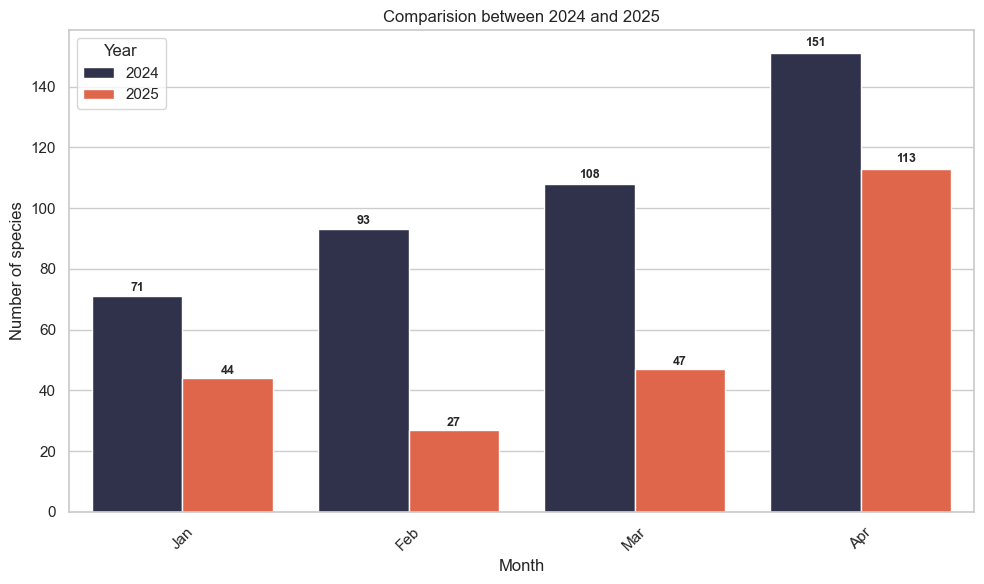

In [22]:
get_species_comp()

# 5. Mapa calor para densidad de observaciones

In [2]:
def get_heatmap(zoom_start:int):

    csv_obs = pd.read_csv(observations_path)

    df_valid = csv_obs.dropna(subset=["latitude", "longitude"])
    heat_data = df_valid[["latitude", "longitude"]].values.tolist()

    mean_lat = df_valid["latitude"].mean()
    mean_lon = df_valid["longitude"].mean()
   

    m = folium.Map(location=[mean_lat, mean_lon], zoom_start=zoom_start)
    HeatMap(heat_data).add_to(m)

    os.makedirs("figures", exist_ok=True)

    html_path = "figures/heatmap.html"
    m.save(html_path)

    img_data = m._to_png(3)
    img = Image.open(io.BytesIO(img_data))
    
    img.save('figures/heatmap_image.png')

In [3]:
get_heatmap(11)